In [3]:
# U-Net Image Segmentation Code

import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Create Synthatic Dataset (Images + Mask)

IMG_SIZE = 128

# 1. Create Synthetic Dataset (Images + Masks)

def create_dataset(samples=300):

  images = []
  masks = []

  for _ in range(samples):
        img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        mask = np.zeros((IMG_SIZE, IMG_SIZE, 1), dtype=np.uint8)

        x = np.random.randint(30, 100)
        y = np.random.randint(30, 100)
        r = np.random.randint(10, 25)

        cv2.circle(img, (x, y), r, (255,255,255), -1)
        cv2.circle(mask, (x, y), r, 255, -1)

        images.append(img/255.0)
        masks.append(mask/255.0)
  return np.array(images), np.array(masks)
X, y = create_dataset()


x_train, x_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=1
)

In [4]:
# 2. Convolution Block

def conv_block(x, filters):
  x = tf.keras.layers.Conv2D (filters, 3, padding="same", activation="relu")(x)
  x = tf.keras.layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
  return x

In [5]:
# 3. Build U-Net Architecture

inputs = tf.keras.layers.Input((IMG_SIZE, IMG_SIZE, 3))

# Encoder

c1 = conv_block(inputs, 32)
p1 = tf.keras.layers.MaxPooling2D()(c1)

c2 = conv_block(p1, 64)
p2 = tf.keras.layers.MaxPooling2D()(c2)

c3 = conv_block(p2, 128)
p3 = tf.keras.layers.MaxPooling2D()(c3)

# Bottleneck

bn = conv_block(p3, 256)

# Decoder

u1 = tf.keras.layers.UpSampling2D()(bn)
concat1 = tf.keras.layers.Concatenate()([u1, c3])
c4 = conv_block(concat1, 128)

u2 = tf.keras.layers.UpSampling2D()(c4)
concat2 = tf.keras.layers.Concatenate()([u2, c2])
c5 = conv_block(concat2, 64)

u3 = tf.keras.layers.UpSampling2D()(c5)
concat3 = tf.keras.layers.Concatenate()([u3, c1])
c6 = conv_block(concat3, 32)

outputs = tf.keras.layers.Conv2D(1, 1, activation="sigmoid")(c6)

model = tf.keras.Model(inputs, outputs)


model.compile(
  optimizer="adam",
  loss="binary_crossentropy",
  metrics=["accuracy"]
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 32, 32,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 32, 32,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 32, 32,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 32, 32,    │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 64, 64,    │          0 │ conv2d_9[0][0]  

 Total params: 1,946,881 (7.43 MB)

 Trainable params: 1,946,881 (7.43 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Train Model

history = model.fit(
  x_train,
  y_train,
  validation_split=0.2,
  epochs=10,
  batch_size=8
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 133ms/step - accuracy: 0.9628 - loss: 0.2868 - val_accuracy: 0.9943 - val_loss: 0.0162
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9976 - loss: 0.0061 - val_accuracy: 0.9984 - val_loss: 0.0038
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9991 - loss: 0.0026 - val_accuracy: 0.9997 - val_loss: 0.0016
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9997 - loss: 0.0013 - val_accuracy: 0.9997 - val_loss: 0.0010
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9989 - loss: 0.0025 - val_accuracy: 0.9990 - val_loss: 0.0022
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9996 - loss: 0.0014 - val_accuracy: 0.9998 - val_loss: 0.0010
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9997 - loss: 9.1601e-04 - val_accuracy: 0.9998 - val_loss: 7.4665e-04
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9998 - loss: 6.7525e-04 - val_accura

In [7]:

# 5. Evaluate Model
loss, acc = model.evaluate(x_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 1.0000 - loss: 3.3526e-04
Test Loss: 0.00033526468905620277
Test Accuracy: 0.9999949336051941


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


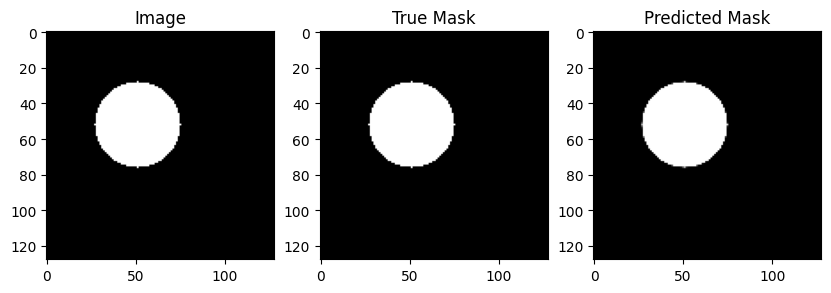

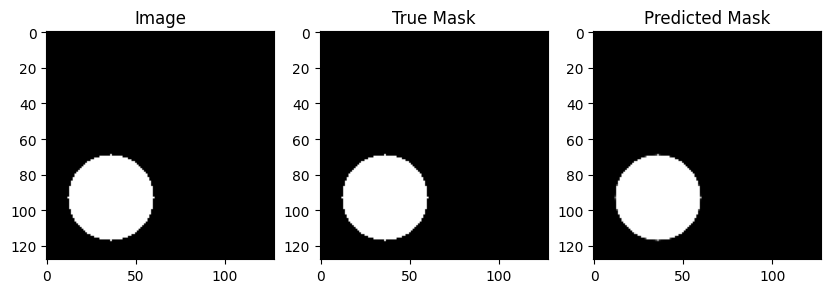

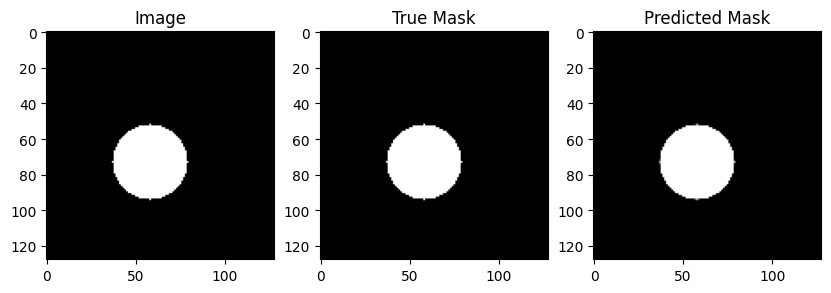

In [8]:

# 6. Predictions
preds = model.predict(x_test[:3])
for i in range(3):

  plt.figure(figsize=(10,3))

  plt.subplot(1,3,1)
  plt.title("Image")
  plt.imshow(x_test[i])

  plt.subplot(1,3,2)
  plt.title("True Mask")
  plt.imshow(y_test[i].squeeze(), cmap="gray")


  plt.subplot(1,3,3)
  plt.title("Predicted Mask")
  plt.imshow(preds[i].squeeze(), cmap="gray")


  plt.show()